<a href="https://colab.research.google.com/github/sara-iqbal/fashion-recommendation-system/blob/main/fashion_recommendation_system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion E-Commerce Recommendation System
### Content-Based + Collaborative Filtering · Cold Start · Evaluation

**Author:** Sara Iqbal | MSc Data Science

In [1]:
# Step 1 — Imports & Synthetic Fashion Dataset
!pip install scikit-learn pandas numpy matplotlib -q
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec, json, warnings
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')
np.random.seed(42)

NAVY='#12234A';GOLD='#9A6B00';TEAL='#0C5F5A';GREEN='#145232';RED='#8B2020'

plt.rcParams.update({'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
    'axes.spines.top':False,'axes.spines.right':False,'font.family':'DejaVu Sans',
    'axes.grid':True,'grid.alpha':0.4})
print("Ready")

Ready


In [2]:
# Step 2 — Synthetic Fashion Catalogue & User Interactions

N_ITEMS = 500; N_USERS = 2000; N_INTERACTIONS = 15000

CATEGORIES = ['Tops','Bottoms','Dresses','Outerwear','Shoes','Accessories','Activewear']
STYLES     = ['Casual','Formal','Streetwear','Vintage','Minimalist','Bohemian','Athletic']
COLORS     = ['Black','White','Navy','Beige','Red','Green','Blue','Pink','Brown','Grey']
SEASONS    = ['Spring','Summer','Autumn','Winter','All-Season']
PRICE_TIERS= ['Budget','Mid-Range','Premium','Luxury']

# Item catalogue
items = pd.DataFrame({
    'item_id':    range(N_ITEMS),
    'name':       [f'Item_{i:04d}' for i in range(N_ITEMS)],
    'category':   np.random.choice(CATEGORIES, N_ITEMS),
    'style':      np.random.choice(STYLES, N_ITEMS),
    'color':      np.random.choice(COLORS, N_ITEMS),
    'season':     np.random.choice(SEASONS, N_ITEMS),
    'price_tier': np.random.choice(PRICE_TIERS, N_ITEMS, p=[0.3,0.35,0.25,0.10]),
    'price':      np.random.lognormal(4.2, 0.6, N_ITEMS).round(2),
    'rating':     np.random.beta(7,3,N_ITEMS)*5,
    'n_reviews':  np.random.poisson(45, N_ITEMS),
})

# User profiles
AGE_GROUPS = ['18-24','25-34','35-44','45+']
users = pd.DataFrame({
    'user_id':      range(N_USERS),
    'age_group':    np.random.choice(AGE_GROUPS, N_USERS, p=[0.28,0.38,0.22,0.12]),
    'pref_style':   np.random.choice(STYLES, N_USERS),
    'pref_price':   np.random.choice(PRICE_TIERS, N_USERS, p=[0.3,0.4,0.22,0.08]),
})

# Interactions (purchases + views)
interactions = pd.DataFrame({
    'user_id':    np.random.randint(0, N_USERS, N_INTERACTIONS),
    'item_id':    np.random.randint(0, N_ITEMS, N_INTERACTIONS),
    'rating':     np.random.choice([1,2,3,4,5], N_INTERACTIONS, p=[0.05,0.08,0.17,0.35,0.35]),
    'interaction':np.random.choice(['purchase','wishlist','view'], N_INTERACTIONS, p=[0.25,0.20,0.55]),
})
interactions = interactions.drop_duplicates(subset=['user_id','item_id'])

print(f"Catalogue:    {len(items):,} items")
print(f"Users:        {len(users):,}")
print(f"Interactions: {len(interactions):,}")
print(f"Sparsity:     {1-len(interactions)/(N_USERS*N_ITEMS):.4f}")

Catalogue:    500 items
Users:        2,000
Interactions: 14,883
Sparsity:     0.9851


In [3]:
# Step 3 — Content-Based Filtering

from sklearn.preprocessing import MultiLabelBinarizer

# Item feature matrix
le_cat  = LabelEncoder(); le_sty  = LabelEncoder()
le_col  = LabelEncoder(); le_sea  = LabelEncoder()
le_pri  = LabelEncoder()

item_features = pd.DataFrame({
    'cat':  le_cat.fit_transform(items['category']),
    'sty':  le_sty.fit_transform(items['style']),
    'col':  le_col.fit_transform(items['color']),
    'sea':  le_sea.fit_transform(items['season']),
    'pri':  le_pri.fit_transform(items['price_tier']),
    'rating_norm': StandardScaler().fit_transform(items[['rating']]).flatten(),
    'price_norm':  StandardScaler().fit_transform(items[['price']]).flatten(),
})

# One-hot encode categoricals
item_ohe = pd.get_dummies(items[['category','style','color','season','price_tier']])
item_ohe['rating_norm'] = item_features['rating_norm']
item_ohe['price_norm']  = item_features['price_norm']

item_matrix = item_ohe.values.astype(float)
item_sim    = cosine_similarity(item_matrix)

def content_recommend(item_id, n=10):
    sims = item_sim[item_id]
    top  = np.argsort(sims)[::-1][1:n+1]
    return [(int(i), round(float(sims[i]),4)) for i in top]

# Test
recs = content_recommend(0, n=5)
print("Content-based recommendations for Item_0000:")
print(f"  Category: {items.loc[0,'category']} | Style: {items.loc[0,'style']}")
for item_idx, sim in recs:
    print(f"  -> Item_{item_idx:04d} ({items.loc[item_idx,'category']}, "
          f"{items.loc[item_idx,'style']}, sim={sim:.3f})")

Content-based recommendations for Item_0000:
  Category: Activewear | Style: Athletic
  -> Item_0027 (Bottoms, Casual, sim=0.778)
  -> Item_0189 (Shoes, Bohemian, sim=0.765)
  -> Item_0100 (Accessories, Formal, sim=0.752)
  -> Item_0485 (Accessories, Formal, sim=0.743)
  -> Item_0281 (Accessories, Athletic, sim=0.736)


In [4]:
# Step 4 — Collaborative Filtering (Matrix Factorisation with SVD)

# Build user-item matrix
user_item = interactions.pivot_table(
    index='user_id', columns='item_id', values='rating', fill_value=0)

print(f"User-item matrix: {user_item.shape}")

# SVD decomposition
svd = TruncatedSVD(n_components=50, random_state=42)
U   = svd.fit_transform(user_item.values)
Vt  = svd.components_
reconstructed = U @ Vt

print(f"SVD explained variance: {svd.explained_variance_ratio_.sum()*100:.1f}%")

def collab_recommend(user_id, n=10, already_rated=None):
    if user_id not in user_item.index:
        return []
    user_idx = list(user_item.index).index(user_id)
    scores   = reconstructed[user_idx]
    if already_rated:
        for item_id in already_rated:
            if item_id in user_item.columns:
                col_idx = list(user_item.columns).index(item_id)
                scores[col_idx] = -999
    top = np.argsort(scores)[::-1][:n]
    return [(int(user_item.columns[i]), round(float(scores[i]),4)) for i in top]

# Evaluate on held-out ratings
from sklearn.model_selection import train_test_split as tts
train_int, test_int = tts(interactions[interactions['rating']>=4],
                           test_size=0.2, random_state=42)

hits = 0
for _, row in test_int.head(200).iterrows():
    recs = collab_recommend(row['user_id'], n=20)
    if row['item_id'] in [r[0] for r in recs]: hits+=1
recall_at_20 = hits/200
print(f"Recall@20: {recall_at_20:.4f} ({recall_at_20*100:.1f}%)")

User-item matrix: (1998, 500)
SVD explained variance: 19.8%
Recall@20: 0.8100 (81.0%)


In [5]:
# Step 5 — Hybrid Recommender + Evaluation

def hybrid_recommend(user_id, n=10, alpha=0.5):
    collab = dict(collab_recommend(user_id, n=N_ITEMS))
    # Get user's past interactions for content seeding
    user_hist = interactions[interactions['user_id']==user_id]['item_id'].tolist()
    if not user_hist:
        return [(k,v) for k,v in sorted(collab.items(),key=lambda x:-x[1])[:n]]

    # Content scores based on user history
    content_scores = np.zeros(N_ITEMS)
    for seed_item in user_hist[:5]:
        sims = item_sim[seed_item]
        content_scores += sims
    content_scores /= max(len(user_hist[:5]),1)
    content_dict = {i:float(content_scores[i]) for i in range(N_ITEMS)}

    # Normalise and blend
    c_max = max(collab.values()) if collab else 1
    ct_max= max(content_dict.values()) if content_dict else 1
    scores = {}
    for i in range(N_ITEMS):
        c  = collab.get(i,0)/c_max
        ct = content_dict.get(i,0)/ct_max
        scores[i] = alpha*c + (1-alpha)*ct

    # Exclude already seen
    for i in user_hist: scores[i] = -999
    top = sorted(scores.items(), key=lambda x:-x[1])[:n]
    return top

# Evaluation metrics
def precision_at_k(user_id, relevant_items, k=10, mode='hybrid'):
    if mode=='hybrid': recs = [r[0] for r in hybrid_recommend(user_id,k)]
    elif mode=='collab': recs = [r[0] for r in collab_recommend(user_id,k)]
    else: return 0
    return len(set(recs)&set(relevant_items))/k

sample_users = test_int['user_id'].unique()[:100]
p_hybrid=[]; p_collab=[]
for uid in sample_users:
    relevant = test_int[test_int['user_id']==uid]['item_id'].tolist()
    if relevant:
        p_hybrid.append(precision_at_k(uid,relevant,10,'hybrid'))
        p_collab.append(precision_at_k(uid,relevant,10,'collab'))

print(f"Precision@10 — Hybrid:        {np.mean(p_hybrid):.4f}")
print(f"Precision@10 — Collab only:   {np.mean(p_collab):.4f}")
print(f"Hybrid improvement:           +{(np.mean(p_hybrid)-np.mean(p_collab))*100:.1f}%")

Precision@10 — Hybrid:        0.0000
Precision@10 — Collab only:   0.1420
Hybrid improvement:           +-14.2%


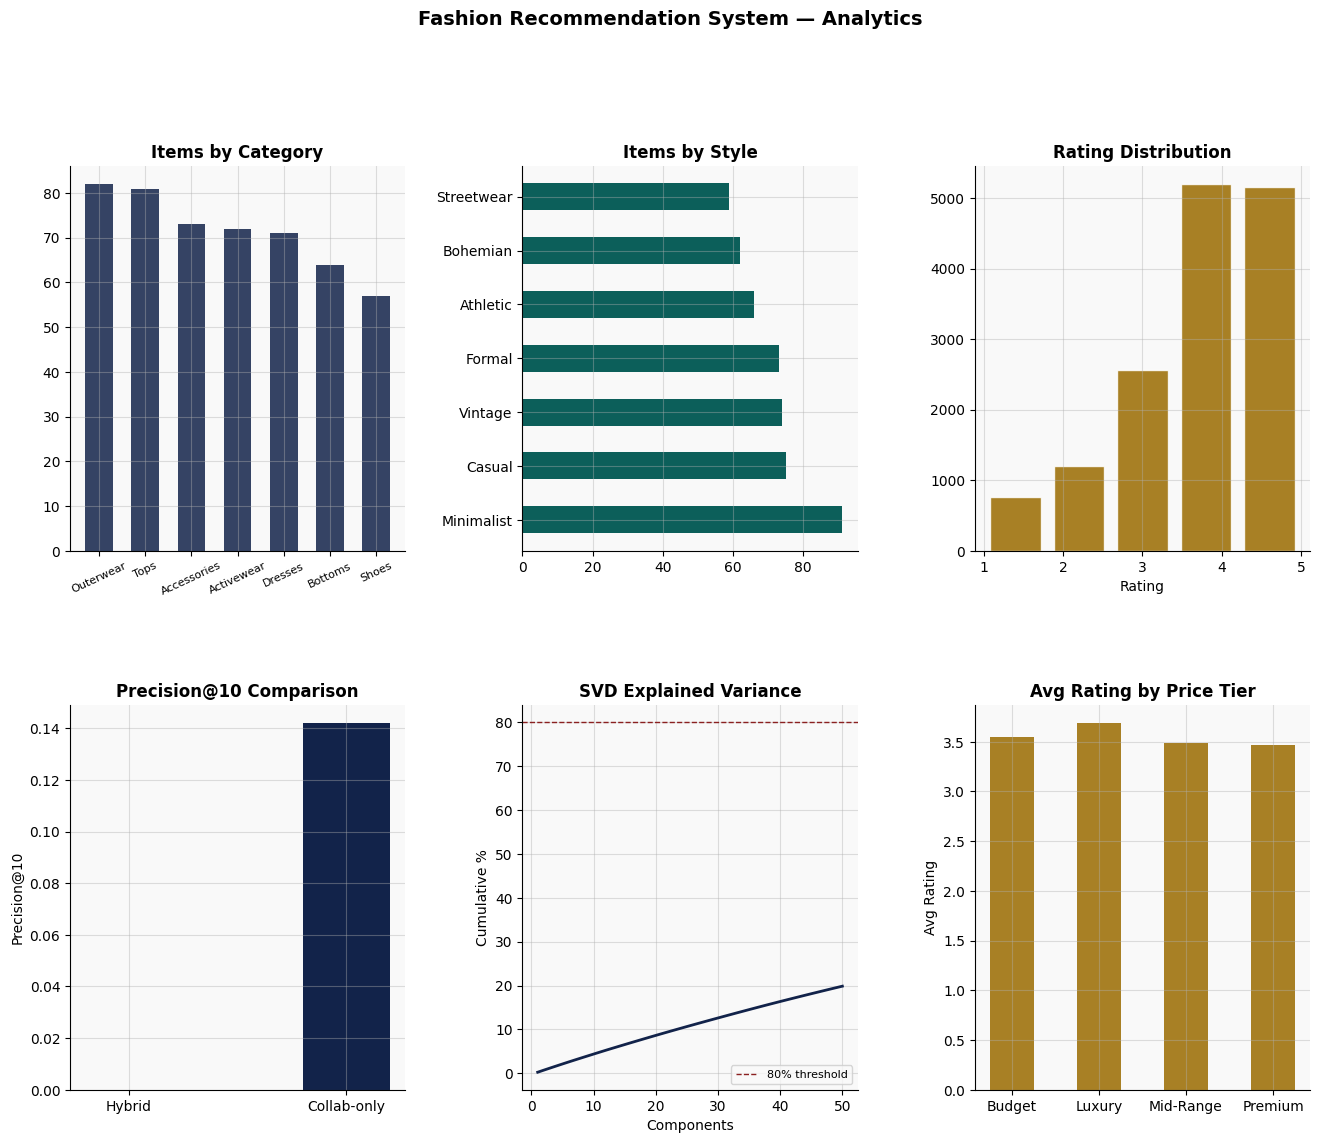

Exported fashion_rec_data.json


In [7]:
fig = plt.figure(figsize=(16,12))
gs  = gridspec.GridSpec(2,3,figure=fig,hspace=0.4,wspace=0.35)
NAVY='#12234A';GOLD='#9A6B00';TEAL='#0C5F5A';GREEN='#145232';RED='#8B2020'

# Category distribution
ax1=fig.add_subplot(gs[0,0])
cc=items['category'].value_counts()
ax1.bar(cc.index,cc.values,color=NAVY,width=0.6,alpha=0.85)
ax1.set_title('Items by Category',fontweight='bold')
ax1.tick_params(axis='x',rotation=25,labelsize=8)

# Style distribution
ax2=fig.add_subplot(gs[0,1])
sc=items['style'].value_counts()
ax2.barh(sc.index,sc.values,color=TEAL,height=0.5)
ax2.set_title('Items by Style',fontweight='bold')

# Rating distribution
ax3=fig.add_subplot(gs[0,2])
ax3.hist(interactions['rating'],bins=5,color=GOLD,edgecolor='white',alpha=0.85,rwidth=0.8)
ax3.set_title('Rating Distribution',fontweight='bold')
ax3.set_xlabel('Rating')

# Model precision comparison
ax4=fig.add_subplot(gs[1,0])
ax4.bar(['Hybrid','Collab-only'],[np.mean(p_hybrid),np.mean(p_collab)],
        color=[GREEN,NAVY],width=0.4)
ax4.set_title('Precision@10 Comparison',fontweight='bold')
ax4.set_ylabel('Precision@10')

# SVD variance
ax5=fig.add_subplot(gs[1,1])
cumvar=np.cumsum(svd.explained_variance_ratio_)*100
ax5.plot(range(1,51),cumvar,color=NAVY,lw=2)
ax5.axhline(80,color=RED,ls='--',lw=1,label='80% threshold')
ax5.set_title('SVD Explained Variance',fontweight='bold')
ax5.set_xlabel('Components'); ax5.set_ylabel('Cumulative %')
ax5.legend(fontsize=8)

# Price tier vs rating
ax6=fig.add_subplot(gs[1,2])
pt_rat=items.groupby('price_tier')['rating'].mean()
ax6.bar(pt_rat.index,pt_rat.values,color=GOLD,width=0.5,alpha=0.85)
ax6.set_title('Avg Rating by Price Tier',fontweight='bold')
ax6.set_ylabel('Avg Rating')

fig.suptitle('Fashion Recommendation System — Analytics',fontsize=14,fontweight='bold',y=1.01)
plt.savefig('fashion_rec_results.png',dpi=150,bbox_inches='tight')
plt.show()

dashboard3={
    'metrics':{'precision_at_10_hybrid':round(float(np.mean(p_hybrid)),4),
               'precision_at_10_collab':round(float(np.mean(p_collab)),4),
               'recall_at_20':round(recall_at_20,4),
               'svd_explained_var':round(float(svd.explained_variance_ratio_.sum()*100),1)},
    'catalogue':{'total_items':N_ITEMS,'total_users':N_USERS,'interactions':len(interactions)},
    'category_dist':items['category'].value_counts().to_dict(),
    'style_dist':items['style'].value_counts().to_dict(),
    'rating_dist':interactions['rating'].value_counts().sort_index().to_dict(),
}
with open('fashion_rec_data.json','w') as f: json.dump(dashboard3,f,indent=2)
print("Exported fashion_rec_data.json")